# Tree growth: Most simple regression model

In this notebook, we will make the simplest possible regression model for the project, modeling growth based only on previous tree height and moisture level. 

<img src="http://mlsm.man.dtu.dk/mbml/wall_street.png">

The relevant imports.

In [11]:
import numpy as np
import pandas as pd   # We import Pandas!
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import linear_model
import torch
import itertools

import pyro
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib options
palette = itertools.cycle(sns.color_palette())
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

Lets start by loading the dataset. In order to let you focus on the probabilistic modelling aspects, we already prepared the raw GPS taxi data for you and extended it with additional information about the weather conditions.

In [12]:
# load csv (original dataset is by 30min intervals, we want 1h intervals) into a Pandas Dataframe
# df = pd.read_csv("https://mlsm.man.dtu.dk/mbml/pickups+weather_wallstreet.csv")

# look at the first few lines of the loaded dataset
# df.head()
df = pd.read_csv(
    "C:\\Users\\rasmu\\OneDrive - Danmarks Tekniske Universitet\\Dokumenter\\MBML project\\data\\out_10km_idx_preprocessed.csv",
    nrows=5000,          # start with a subset
    low_memory=False
)

df.head()


,x,y,biomassa_omdrev1,biomassa_omdrev2,flodesackumulering,grundyta_omdrev1,grundyta_omdrev2,markfuktighet,markfuktighet_klassad,medeldiameter_omdrev1,...,CenterLanNamn,CenterKommunNamn,is_no_forest,is_lake,delta_neg_medelhojd,delta_neg_p95,delta_neg_medeldiameter,delta_neg_biomassa,delta_neg_volym,is_stable_forest
0,445881.25,6260468.75,79.0,113.0,0.018730,22.0,23.0,97.0,2.0,15.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
1,445893.75,6260468.75,65.0,96.0,0.121874,17.0,20.0,99.0,2.0,18.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
2,445906.25,6260468.75,76.0,117.0,0.014839,21.0,24.0,99.0,2.0,15.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
3,445918.75,6260468.75,68.0,113.0,0.004559,19.0,23.0,85.0,2.0,14.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
4,445931.25,6260468.75,76.0,136.0,0.001676,21.0,27.0,82.0,2.0,14.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True


Filtering on "Is_stable_forest" 

In [13]:
# Keep only stable-forest rows
col_lookup = {c.lower(): c for c in df.columns}
stable_col = col_lookup.get("is_stable_forest")

# Fallback: find a likely stable-forest column if naming differs.
if stable_col is None:
    candidates = [
        c for c in df.columns
        if ("stable" in c.lower()) and ("forest" in c.lower())
    ]
    stable_col = candidates[0] if candidates else None

if stable_col is None:
    raise KeyError("No stable-forest column found (expected something like 'Is_stable_forest').")

stable_raw = df[stable_col]
if pd.api.types.is_bool_dtype(stable_raw):
    stable_mask = stable_raw
else:
    stable_mask = stable_raw.astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

df = df.loc[stable_mask].copy()
print(f"Using stable-forest column: {stable_col}")
print(f"Rows after stable-forest filter: {len(df)}")
df.head()

Using stable-forest column: is_stable_forest
Rows after stable-forest filter: 2003


,x,y,biomassa_omdrev1,biomassa_omdrev2,flodesackumulering,grundyta_omdrev1,grundyta_omdrev2,markfuktighet,markfuktighet_klassad,medeldiameter_omdrev1,...,CenterLanNamn,CenterKommunNamn,is_no_forest,is_lake,delta_neg_medelhojd,delta_neg_p95,delta_neg_medeldiameter,delta_neg_biomassa,delta_neg_volym,is_stable_forest
0,445881.25,6260468.75,79.0,113.0,0.018730,22.0,23.0,97.0,2.0,15.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
1,445893.75,6260468.75,65.0,96.0,0.121874,17.0,20.0,99.0,2.0,18.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
2,445906.25,6260468.75,76.0,117.0,0.014839,21.0,24.0,99.0,2.0,15.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
3,445918.75,6260468.75,68.0,113.0,0.004559,19.0,23.0,85.0,2.0,14.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True
4,445931.25,6260468.75,76.0,136.0,0.001676,21.0,27.0,82.0,2.0,14.0,...,SKÅNE LÄN,OSBY,False,False,False,False,False,False,False,True


The model considers growth as a function of various forest characteristics including tree dimensions, volume, biomass, and soil wetness.



In [14]:
# prepare matrix with selected domain features (explicit list)
requested_cols = [
    "biomassa_omdrev1",
    "grundyta_omdrev1",
    "medeldiameter_omdrev1",
    "medelhojd_omdrev1",
    "p95_omdrev1",
    "vegetationskvot_omdrev1",
    "volym_omdrev1",
    "flodesackumulering",
    "markfuktighet",
]

available_cols = [c for c in requested_cols if c in df.columns]
missing_cols = [c for c in requested_cols if c not in df.columns]

if not available_cols:
    X_selected = np.empty((len(df), 0))
    X_weather = X_selected
    print("None of the requested columns were found in df.")
else:
    # Convert selected columns to numeric and handle missing values.
    X_selected = (
        df[available_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .values
    )

    # Keep existing downstream code compatible.
    X_weather = X_selected

    print(f"Using {len(available_cols)} requested columns")
    print(available_cols)
    if missing_cols:
        print(f"Missing {len(missing_cols)} requested columns")
        print(missing_cols)
    print(X_weather.shape)

Using 9 requested columns
['biomassa_omdrev1', 'grundyta_omdrev1', 'medeldiameter_omdrev1', 'medelhojd_omdrev1', 'p95_omdrev1', 'vegetationskvot_omdrev1', 'volym_omdrev1', 'flodesackumulering', 'markfuktighet']
(2003, 9)


In [15]:
# prepare target as growth in mean height between omdrev2 and omdrev1
y_raw = (
    pd.to_numeric(df["medelhojd_omdrev2"], errors="coerce")
    - pd.to_numeric(df["medelhojd_omdrev1"], errors="coerce")
)

# Fill any missing values before standardization.
y = y_raw.fillna(0.0).values

# standardize target
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / y_std
print(y.shape)
print(f"Target mean (before standardization): {y_mean:.4f}")
print(f"Target std (before standardization): {y_std:.4f}")

(2003,)
Target mean (before standardization): 35.1907
Target std (before standardization): 27.1310


The X matrix now contain all the input data for the model, and the y vector contains all the corresponding targets (growth).

The next step is to split our data into a train and test set. Alternatively, we could have used something like cross-validation, but for the sake of simplicity, a train/test split will do just fine for this example.

In [16]:
train_perc = 0.66  # percentage of training data
split_point = int(train_perc * len(y))
perm = np.random.permutation(len(y))
ix_train = perm[:split_point]
ix_test = perm[split_point:]

# Use the selected feature matrix as model input.
X = X_weather
X_train = X[ix_train, :]
X_test = X[ix_test, :]
y_train = y[ix_train]
y_test = y[ix_test]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("num train: %d" % len(y_train))
print("num test: %d" % len(y_test))

# ADD THIS:
# Standardize input features
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8  # avoid division by zero
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std
print("\nFeatures standardized:")
print(f"X_train mean: {X_train.mean(axis=0)}")
print(f"X_train std: {X_train.std(axis=0)}")

print(f"y_train mean: {y_train.mean():.4f}")
print(f"y_train std: {y_train.std():.4f}")

X_train shape: (1321, 9)
X_test shape: (682, 9)
num train: 1321
num test: 682

Features standardized:
X_train mean: [-1.50439002e-17 -1.46236795e-17 -8.64814150e-17 -6.38735427e-18
  1.41530324e-16  2.09269896e-17  3.66852650e-17 -9.42344865e-18
  4.53838330e-17]
X_train std: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
y_train mean: -0.0250
y_train std: 0.9297


A crucial step in developing a experimental setup in machine learning is establishing how to access the quality of the models that we learn. For this purpose, we developed a funciton which already constains a series of popular metrics for evaluating the quality of the predictions of a regression model (continuous output variables!). Here we just reuse the assesment from class, but it might be relevant to consider changing. 

In [17]:
def compute_error(trues, predicted):
    corr = np.corrcoef(predicted, trues)[0,1]
    mae = np.mean(np.abs(predicted - trues))
    rae = np.sum(np.abs(predicted - trues)) / np.sum(np.abs(trues - np.mean(trues)))
    rmse = np.sqrt(np.mean((predicted - trues)**2))
    r2 = max(0, 1 - np.sum((trues-predicted)**2) / np.sum((trues - np.mean(trues))**2))
    return corr, mae, rae, rmse, r2

I just added some data inspection for debugging and to see what's going on. The data has been standardized. 

In [18]:
# Inspect data quality
print("="*50)
print("DATA QUALITY CHECK")
print("="*50)
print("\nX_train stats:")
print(f"  Mean: {X_train.mean(axis=0)}")
print(f"  Std: {X_train.std(axis=0)}")
print(f"  Min: {X_train.min(axis=0)}")
print(f"  Max: {X_train.max(axis=0)}")

print("\ny_train stats:")
print(f"  Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")

print("\nCorrelation with target:")
for i, col in enumerate(available_cols):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    print(f"  {col}: {corr:.4f}")
print("="*50 + "\n")

DATA QUALITY CHECK

X_train stats:
  Mean: [-1.50439002e-17 -1.46236795e-17 -8.64814150e-17 -6.38735427e-18
  1.41530324e-16  2.09269896e-17  3.66852650e-17 -9.42344865e-18
  4.53838330e-17]
  Std: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Min: [-1.20367851 -1.50740982 -1.53212853 -1.5747366  -1.502849   -1.52249576
 -1.10125904 -0.11864538 -1.46326978]
  Max: [ 4.32142027  2.88169562  2.88869084  2.36016645  2.47859016  1.491647
  4.53756573 19.40480901  1.28826312]

y_train stats:
  Mean: -0.0250, Std: 0.9297

Correlation with target:
  biomassa_omdrev1: -0.5011
  grundyta_omdrev1: -0.5338
  medeldiameter_omdrev1: -0.5831
  medelhojd_omdrev1: -0.5945
  p95_omdrev1: -0.5861
  vegetationskvot_omdrev1: -0.4880
  volym_omdrev1: -0.4767
  flodesackumulering: -0.0209
  markfuktighet: -0.1340



For the sake of comparision, we compare to linear regression from the sklearn package.

In [19]:
#regr = linear_model.LinearRegression()
regr = linear_model.Ridge()
regr.fit(X_train, y_train)
y_hat = regr.predict(X_test)

# Convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.560
MAE: 13.670
RMSE: 25.328
R2: 0.308


### Pyro: Train on a small subset of the data

We implement Bayesian linear regression in Pyro!

We keep the intercept $\alpha$, and I (copilot) adjusted the prior for $\beta$, as with the original the posteriors were essentially 1. The structure is still as before. 

$y_n \sim \mathcal{N}(\alpha + \boldsymbol\beta^T \textbf{x}_n , \sigma^2)$

In [20]:
def model(X, obs=None):
    alpha = pyro.sample("alpha", dist.Normal(0., 1.))
    # CHANGE THIS LINE:
    beta  = pyro.sample("beta", dist.Normal(torch.zeros(X.shape[1]), 
                                            torch.ones(X.shape[1]) * 10.0).to_event())  # Weaker prior
    sigma = pyro.sample("sigma", dist.HalfCauchy(5.))
    
    with pyro.plate("data"):
        y = pyro.sample("y", dist.Normal(alpha + X.matmul(beta), sigma), obs=obs)
        
    return y

We begin by doing inference on the model using MCMC (NUTS) and using only a small subsample of the dataset.

In [21]:
# Prepare data for Pyro model
X_train_small = torch.tensor(X_train[:100,:]).float()
y_train_small = torch.tensor(y_train[:100]).float()

Please run the above model, with the corresponding data

In [22]:
# Run inference in Pyro
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=200, num_chains=1)
mcmc.run(X_train_small, y_train_small)

# Show summary of inference results
mcmc.summary()

Sample: 100%|██████████| 1200/1200 [04:01,  4.96it/s, step size=2.55e-02, acc. prob=0.932]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      0.06      0.09      0.05     -0.11      0.20    751.37      1.00
   beta[0]      0.84      0.81      0.79     -0.41      2.24    613.73      1.00
   beta[1]     -0.67      0.95     -0.68     -2.34      0.72    336.87      1.01
   beta[2]      0.80      1.42      0.80     -1.66      2.99    476.73      1.00
   beta[3]     -2.75      2.76     -2.68     -7.23      1.78    364.34      1.01
   beta[4]      0.86      1.72      0.86     -2.00      3.52    478.57      1.01
   beta[5]      0.30      0.42      0.30     -0.42      0.97    487.56      1.00
   beta[6]      0.07      0.74      0.08     -1.11      1.26    366.84      1.01
   beta[7]      0.04      0.11      0.04     -0.13      0.23   1089.76      1.00
   beta[8]     -0.07      0.09     -0.07     -0.21      0.08   1043.78      1.00
     sigma      0.84      0.06      0.83      0.72      0.93   1257.09      1.00

Number of divergences: 0


Plot the posterior distribution of all the latent variables in the model (alpha, betas and sigma).

C:\Users\rasmu\AppData\Local\Temp\ipykernel_36916\2542243133.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(posterior_samples["alpha"])
C:\Users\rasmu\AppData\Local\Temp\ipykernel_36916\2542243133.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(posterior_samples["sigma"])


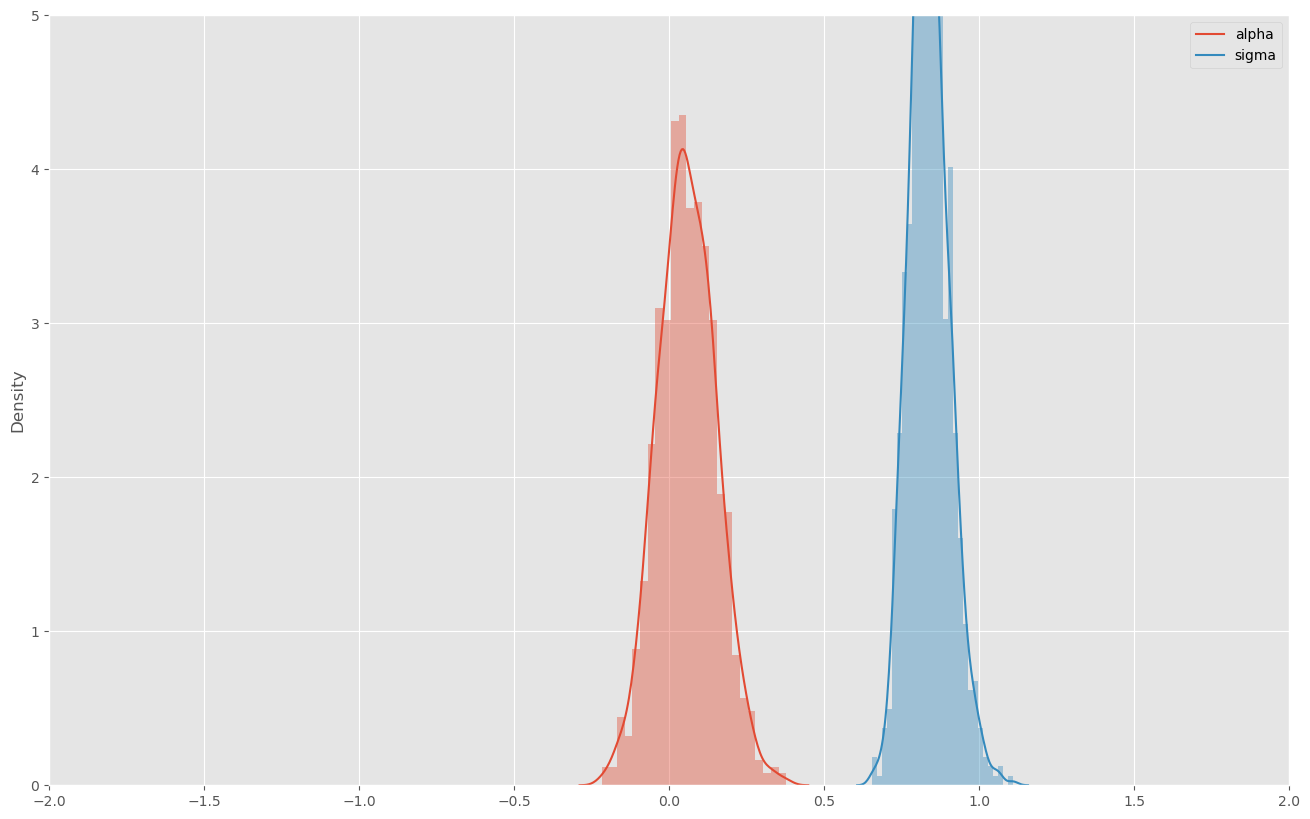

In [23]:
# Extract samples from posterior
posterior_samples = mcmc.get_samples()

sns.distplot(posterior_samples["alpha"])
sns.distplot(posterior_samples["sigma"])

# Alternate plotting due to deprecated distplot-function
#sns.histplot(data=posterior_samples["alpha"], kde=True, stat='density', color=next(palette), element="step")
#sns.histplot(data=posterior_samples["sigma"], kde=True, stat='density', color=next(palette), element="step")

plt.legend(["alpha", "sigma"])
plt.axis([-2,2,0,5])
plt.show()

C:\Users\rasmu\AppData\Local\Temp\ipykernel_36916\995237761.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(posterior_samples["beta"][:,i])
C:\Users\rasmu\AppData\Local\Temp\ipykernel_36916\995237761.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(posterior_samples["beta"][:,i])
C:\Users

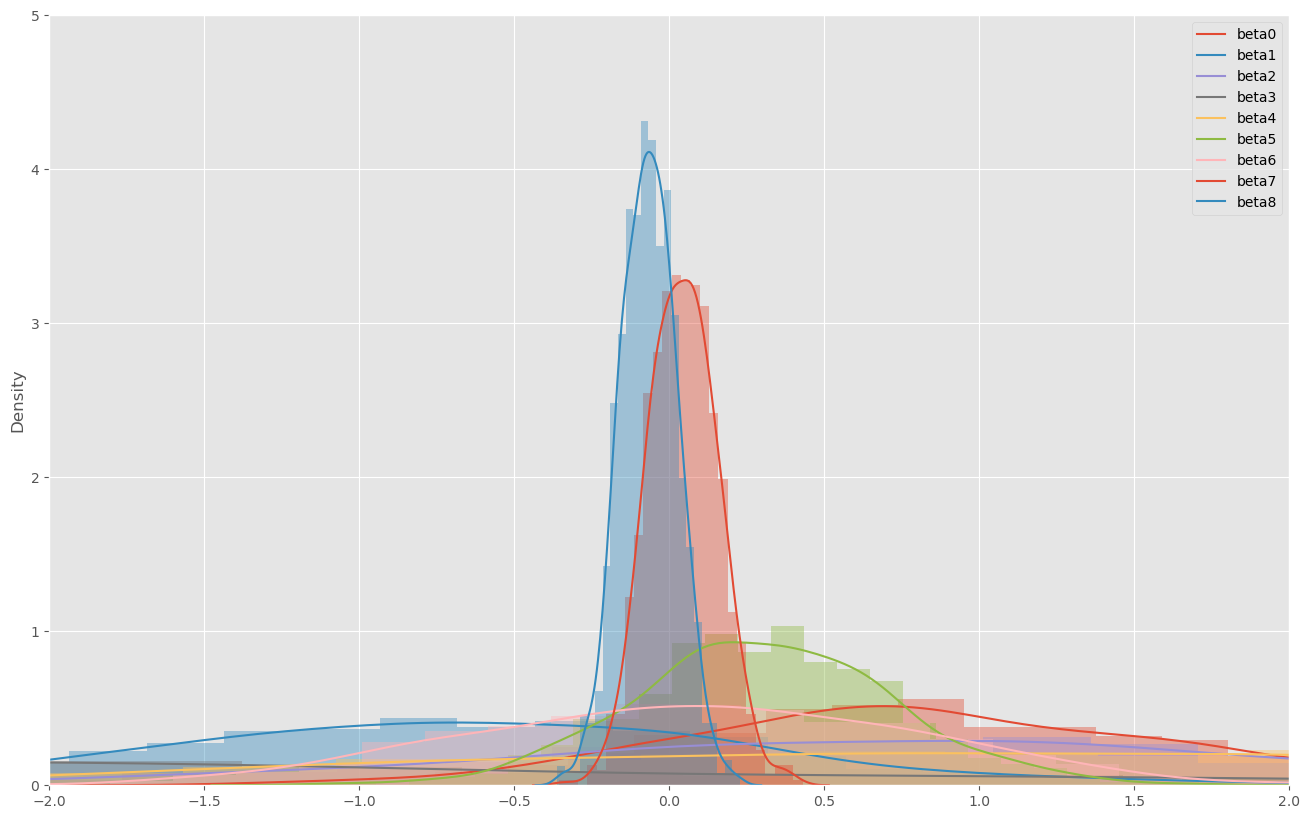

In [24]:
for i in range(X.shape[1]):
    sns.distplot(posterior_samples["beta"][:,i])

    # Alternative to avoid warnings
    #sns.histplot(posterior_samples["beta"][:,i], kde=True, color=next(palette), stat='density', element='step')

plt.legend(["beta%d" % i for i in range(X.shape[1])])
plt.axis([-2,2,0,5])
plt.show()

Given the posterior distributions over the variables alpha and beta, we can make predictions for the test set. In this case there are multiple ways to do this! Lets see...

First, recall that the output of Pyro consists of samples from the posterior distribution of the latent variables (in this case, ```alpha```, ```beta``` and ```sigma```). We can use these samples to compute the mean (or mode!) of the posterior distribution over alpha and beta ($\hat{\alpha}$ and $\hat{\boldsymbol\beta}$, respectively), and then use that mean/mode to make predictions $\hat{y}$ as follows:

$\hat{y}_n = \hat{\alpha} + \hat{\boldsymbol\beta}^T \textbf{x}_n$

Can you create a vector called "y_hat" with the predictions for the test set?

In [25]:
print(posterior_samples["alpha"].shape)
print(posterior_samples["beta"].shape)

beta_hat=torch.mean(posterior_samples["beta"], axis=0)
alpha_hat=torch.mean(posterior_samples["alpha"], axis=0)

y_hat = alpha_hat+np.dot(X_test,beta_hat)

torch.Size([1000])
torch.Size([1000, 9])


C:\Users\rasmu\AppData\Local\Temp\ipykernel_36916\1218431680.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_hat = alpha_hat+np.dot(X_test,beta_hat)
C:\Users\rasmu\AppData\Local\Temp\ipykernel_36916\1218431680.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_hat = alpha_hat+np.dot(X_test,beta_hat)


Since we standardized the target variable $y$ (tree growth) before feeding it to the Pyro model, we need to convert the predictions back to original scale before evaluating their quality:

In [26]:
# Convert back to the original scale
preds = y_hat.numpy() * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.560
MAE: 14.456
RMSE: 25.280
R2: 0.311


What we just did for making predictions seems a bit wasteful. Pyro just computed for us the (whole!) posterior distribution for alpha and beta, and we completely ignored it by looking at its mean (or mode) and using that to make predictions. Furthermore, why use the mean instead of the mode (or vice-versa)? For sure there must be a better way...

Indeed, the proper Bayesian way of making predictions for our Bayesian linear regression model is to follow the rules of probability. Namely, our goal in prediction is to use the posterior over $\alpha$ and $\boldsymbol\beta$ given the observed data, $p(\alpha | \textbf{y}, \textbf{X})$ and $p(\boldsymbol\beta | \textbf{y}, \textbf{X})$ respectively, to compute the posterior distribution of the target variable $y_*$ for a new input vector $\textbf{x}_*$ as follows:

$p(y_* | \textbf{x}_*, \textbf{y}, \textbf{X}, \sigma) = \int \int \mathcal{N}(y_* | \alpha + \boldsymbol\beta^T \textbf{x}_*, \sigma^2) \, p(\alpha | \textbf{y}, \textbf{X}) \, p(\boldsymbol\beta | \textbf{y}, \textbf{X}) \, d\alpha \, d\boldsymbol\beta$

Notice that we are integrating (or marginalizing) over all values of $\alpha$ and $\boldsymbol\beta$. We can think of this as averaging over the values of $\alpha$ and $\boldsymbol\beta$ according to their posterior distributions.

Since Pyro outputs a set of $S$ samples from the posteriors, $\{\alpha^{(s)}, \boldsymbol\beta^{(s)}\}_{s=1}^S$, we can easily use them to approximate the expected value of $y_*$ as follows:

$\mathbb{E}[y_*] \approx \frac{1}{S} \sum_{s=1}^S \alpha^{(s)} + (\boldsymbol\beta^{(s)})^T \textbf{x}_*$

So lets do that!

In [27]:
y_hat = np.mean(posterior_samples["alpha"].numpy().T + np.dot(X_test, posterior_samples["beta"].numpy().T), axis=1)

We can evaluate the (new) predictions:

In [28]:
# Convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.560
MAE: 14.456
RMSE: 25.280
R2: 0.311


Did you get similar error values as before? Probably they didn't change much in this case, because the posteriors of $\alpha$ and $\boldsymbol\beta$ look very Gaussian and also because our likelihood is Gaussian too! But if the posteriors were skewed or multimodal, then this approximation to the Bayesian integral would likely yield quite different results from the ones obtained by using the mean or the mode of the posterior distribution. Therefore, this is something important to be aware of!

### Pyro: Train on a slightly larger subset of the data

We will now do inference on a slightly larget subset of the data, and see what happens...

In [29]:
# Prepare data for Pyro model
X_train_small = torch.tensor(X_train[:1000,:]).float()
y_train_small = torch.tensor(y_train[:1000]).float()

In [30]:
# Run inference in Pyro
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=200, num_chains=1)
mcmc.run(X_train_small, y_train_small)

# Show summary of inference results
mcmc.summary()

Sample: 100%|██████████| 1200/1200 [04:01,  4.96it/s, step size=2.21e-02, acc. prob=0.938]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha     -0.02      0.02     -0.02     -0.06      0.01    841.26      1.00
   beta[0]      0.24      0.25      0.23     -0.14      0.64    447.04      1.00
   beta[1]     -0.45      0.22     -0.45     -0.78     -0.08    572.29      1.00
   beta[2]      0.23      0.22      0.23     -0.12      0.56    769.24      1.00
   beta[3]     -1.10      0.60     -1.12     -2.03     -0.11    537.57      1.00
   beta[4]      0.22      0.51      0.21     -0.64      1.00    593.45      1.00
   beta[5]      0.10      0.10      0.10     -0.09      0.24    690.85      1.00
   beta[6]      0.25      0.22      0.25     -0.08      0.63    370.25      1.00
   beta[7]     -0.01      0.02     -0.01     -0.05      0.03   1039.71      1.00
   beta[8]     -0.09      0.02     -0.09     -0.13     -0.05    606.76      1.00
     sigma      0.72      0.02      0.72      0.69      0.75   1305.75      1.00

Number of divergences: 0


Plot the posterior distribution of all the latent variables in the model (alpha, betas and sigma).

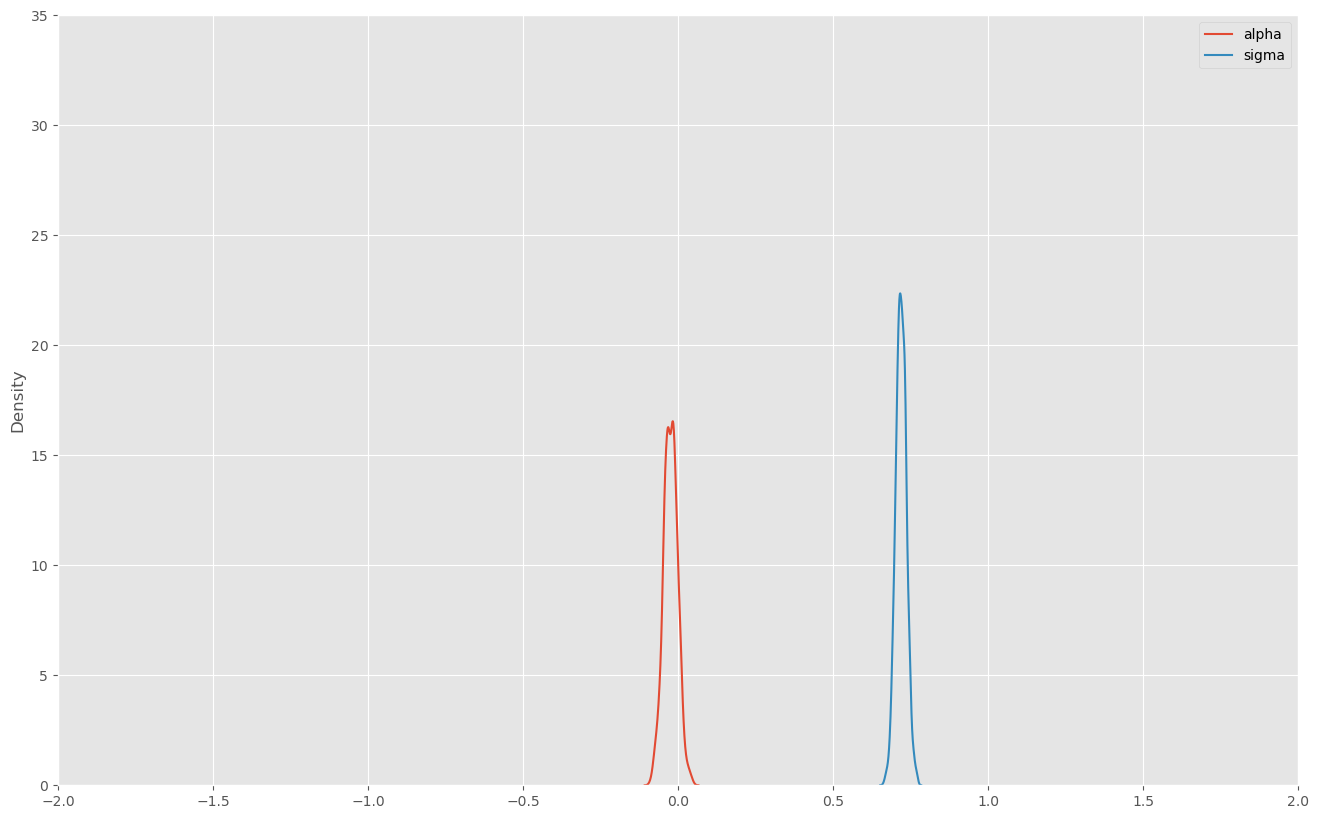

In [31]:
# Extract samples from posterior
posterior_samples = mcmc.get_samples()

sns.kdeplot(posterior_samples["alpha"])
sns.kdeplot(posterior_samples["sigma"])

# Alternative
#sns.histplot(data=posterior_samples["alpha"], kde=True, stat='density', color=next(palette), element="step")
#sns.histplot(data=posterior_samples["sigma"], kde=True, stat='density', color=next(palette), element="step")

plt.legend(["alpha", "sigma"])
plt.axis([-2,2,0,35])
plt.show()

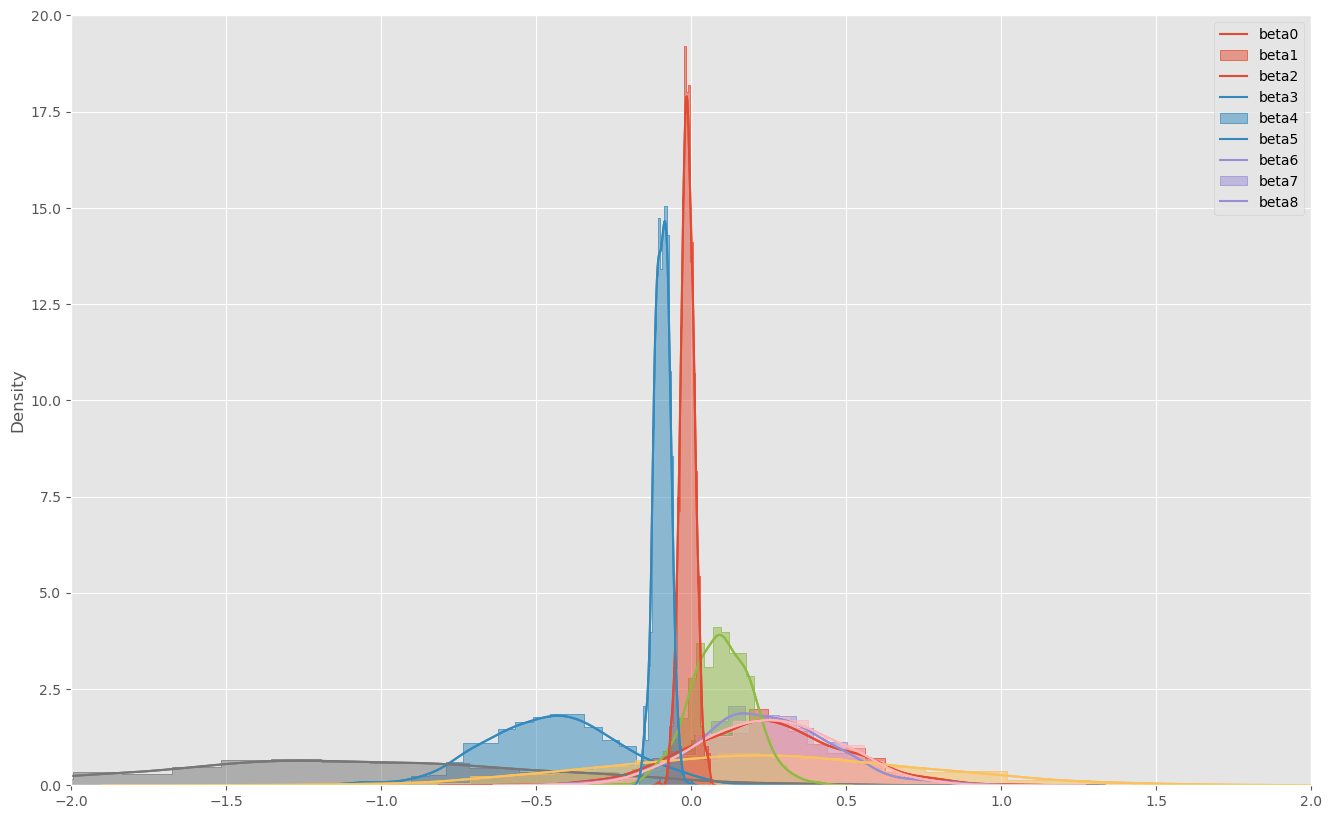

In [32]:
for i in range(X.shape[1]):
    sns.kdeplot(posterior_samples["beta"][:,i])
    # Alternative
    sns.histplot(data=posterior_samples["beta"][:,i], kde=True, stat='density', color=next(palette), element="step")
plt.legend(["beta%d" % i for i in range(X.shape[1])])
plt.axis([-2,2,0,20])
plt.show()

Compare the new posterior distributions with the ones obtained by using only 100 data points from the dataset (above). Be careful with the scales of the plots...

Notice how the model is now much more confident about the posterior distribution of the latent variables in the model (narrower distributions; lower uncertainty in the estimates). This makes sense! The more data we observe, the more confident we become about our estimates.

Now, lets extract the posterior samples from Pyro and make predictions for the test set

In [33]:
# Extract samples from posterior
posterior_samples = mcmc.get_samples()

# Compute predictions
y_hat = np.mean(posterior_samples["alpha"].numpy().T + np.dot(X_test, posterior_samples["beta"].numpy().T), axis=1)

And lets check the error statistics...

In [34]:
# Convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.561
MAE: 13.617
RMSE: 25.353
R2: 0.307



Better, right? But this took quite longer to run, and in this case didn't necessarily beat "sklearn"...

MCMC methods have great properties, namely the fact that in the limit of infinite computation time they will converge to the true posterior distribution. However, they often have difficulty scaling to larger datasets. 

### Pyro: Train on full dataset using Stochastic Variational Inference (SVI)

SVI on the other hand is much more scalable. Let us now try to use SVI to perform inference in our model. We start by preparing the data by converting it to torch tensors:

In [35]:
# Prepare data for Pyro model
X_train_torch = torch.tensor(X_train).float()
y_train_torch = torch.tensor(y_train).float()

As we briefly touched upon during the notebook from last lecture (and also in the slides), in VI we specify a parametric distribution $q(\textbf{z}|\boldsymbol\phi)$ (called the *variational distribution*) with parameters $\boldsymbol\phi$. The goal is the to find the values of the parameters $\boldsymbol\phi$ that make $q(\textbf{z}|\boldsymbol\phi)$ and close as possible to the true posterior distribution $p(\textbf{z}|\textbf{x})$, thereby turning the problem of Bayesian inference into an optimization problem. We will get back to explain VI in detail later on in the course, but for now this is the essential that you need to know to use it in Pyro. 

In Pyro, the variational distribution is specified in a ```guide```, just like the model function. In fact, there are classes (e.g. ```AutoDiagonalNormal``` and ```AutoMultivariateNormal```) that generate the guide function automatically: 

In [36]:
# Define guide function
guide = AutoMultivariateNormal(model)

# Reset parameter values
pyro.clear_param_store()

Notice that we also reset the storage of Pyro parameters using ```pyro.clear_param_store()```. This is particularly important when running inference on the same model multiple times, because otherwise, Pyro will remember and re-use the parameter values from the last execution.

As mentioned above, in VI, the problem of (approximate) Bayesian inference is turned into an optimization problem. Like any other numerical optimization problem, we need to specify the optimizer (in this case ```ClippedAdam``` - a gradient descent algorithm that cleverly adapts the step size), an objective or loss function (```Trace_ELBO``` - this is the default that you will almost always use), and other details like the learning rate of the optimizer and the number of optimization steps:

In [37]:
# Define the number of optimization steps
n_steps = 4000

# Setup the optimizer
adam_params = {"lr": 0.001} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model, guide, optimizer, loss=elbo)

The last step above was to instantiate ```SVI``` with the ```model```, ```guide```, ```optimizer``` and loss function (```elbo```) that we have just defined. Once this is done, we can solve this optimization problem by taking steps in the direction of the gradient using the function ```svi.step(...)```:

In [38]:
# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X_train_torch, y_train_torch)
    if step % 100 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 16353.1
[100] ELBO: 14067.5
[200] ELBO: 12190.2
[300] ELBO: 10933.7
[400] ELBO: 8609.7
[500] ELBO: 7048.9
[600] ELBO: 6727.6
[700] ELBO: 6013.1
[800] ELBO: 5839.8
[900] ELBO: 5948.6
[1000] ELBO: 5453.6
[1100] ELBO: 5305.7
[1200] ELBO: 5318.9
[1300] ELBO: 5244.6
[1400] ELBO: 5135.0
[1500] ELBO: 5089.0
[1600] ELBO: 5001.4
[1700] ELBO: 4902.6
[1800] ELBO: 4806.8
[1900] ELBO: 4680.7
[2000] ELBO: 4638.4
[2100] ELBO: 4553.5
[2200] ELBO: 4424.5
[2300] ELBO: 4219.4
[2400] ELBO: 4043.2
[2500] ELBO: 4006.9
[2600] ELBO: 3802.9
[2700] ELBO: 3676.3
[2800] ELBO: 3545.8
[2900] ELBO: 3446.3
[3000] ELBO: 3322.4
[3100] ELBO: 3274.6
[3200] ELBO: 3142.4
[3300] ELBO: 3072.7
[3400] ELBO: 3116.8
[3500] ELBO: 3047.5
[3600] ELBO: 2980.8
[3700] ELBO: 2986.3
[3800] ELBO: 2901.7
[3900] ELBO: 2828.5


If all went well, the values of the loss function in the output above should be going down. They can ocasionally go up, because Pyro estimates stochastic gradients (i.e. a noisy approximation to the gradients that, although imperfect is very efficient and scalable), but overall trend should be for the values of the loss function to go down. 

Once the optimization has converged to a minimum, we can use the ```Predictive``` class to extract the results. The usage is similar to what we did with MCMC, although we now must pass the guide to the ```Predictive``` class as well:

In [39]:
from pyro.infer import Predictive

predictive = Predictive(model, guide=guide, num_samples=1000,
                        return_sites=("alpha", "beta", "sigma"))
samples = predictive(X_train_torch, y_train_torch)

We can now use the samples from the posterior distribution above to make predictions for the test set:

In [40]:
alpha_samples = samples["alpha"].detach().numpy()
beta_samples = samples["beta"].detach().numpy()
y_hat = np.mean(alpha_samples.T + np.dot(X_test, beta_samples[:,0].T), axis=1)

# convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))


CorrCoef: 0.017
MAE: 41.545
RMSE: 56.293
R2: 0.000


## 2.3 Pyro: Heteroscedastic regression

Ok, let us now assume again that the Gaussian likelihood was indeed the most appropriate choice. In many problems of interest, it is often the case that constant observation variance ($\sigma^2$) is too limiting or inadequate. We can relax this assumption by considering heteroscedastic models, in which the observation variance is assumed to be non-constant and dependent on any other variables. In this particular case, we shall assume that the observation variance is also linearly dependent on the inputs $\textbf{x}$. 

Lets implement this model in Pyro (check the lecture slides, if necessary)!

In [41]:
def heteroscedastic_model(X, obs=None):
    alpha_mu = pyro.sample("alpha_mu", dist.Normal(0., 1.))                 # Prior for the bias/intercept of the mean
    beta_mu  = pyro.sample("beta_mu", dist.Normal(torch.zeros(X.shape[1]), 
                                               torch.ones(X.shape[1])).to_event())     # Priors for the regression coeffcients of the mean
    alpha_v = pyro.sample("alpha_v", dist.Normal(0., 1.))                   # Prior for the bias/intercept of the variance
    beta_v  = pyro.sample("beta_v", dist.Normal(torch.zeros(X.shape[1]), 
                                               torch.ones(X.shape[1])).to_event())     # Priors for the regression coeffcients of the variance
    
    with pyro.plate("data"):
        y = pyro.sample("y", dist.Normal(alpha_mu + X.matmul(beta_mu), torch.exp(alpha_v + X.matmul(beta_v))), obs=obs)
        
    return y

Once you finished coding the model, it is time to run inference on it. Feel free to play with the hyper-parameters of the optimization (i.e. ```n_steps```, learning rate ```lr```, etc.):

In [42]:
# Prepare data for Pyro model
X_train_torch = torch.tensor(X_train).float()
y_train_torch = torch.tensor(y_train).float()

In [43]:
# Define guide function
guide = AutoMultivariateNormal(heteroscedastic_model)

# Reset parameter values
pyro.clear_param_store()

# Define the number of optimization steps
n_steps = 8000

# Setup the optimizer
adam_params = {"lr": 0.001} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(heteroscedastic_model, guide, optimizer, loss=elbo)

# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X_train_torch, y_train_torch)
    if step % 200 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 1616161.6
[200] ELBO: 3482.8
[400] ELBO: 2146.9
[600] ELBO: 1905.0
[800] ELBO: 1747.0
[1000] ELBO: 1793.3
[1200] ELBO: 1324.1
[1400] ELBO: 1288.5
[1600] ELBO: 1307.2
[1800] ELBO: 1244.5
[2000] ELBO: 1213.5
[2200] ELBO: 1262.0
[2400] ELBO: 1225.7
[2600] ELBO: 1209.9
[2800] ELBO: 1204.6
[3000] ELBO: 1236.4
[3200] ELBO: 1194.3
[3400] ELBO: 1201.5
[3600] ELBO: 1190.2
[3800] ELBO: 1192.0
[4000] ELBO: 1202.7
[4200] ELBO: 1186.3
[4400] ELBO: 1178.8
[4600] ELBO: 1182.3
[4800] ELBO: 1198.5
[5000] ELBO: 1185.9
[5200] ELBO: 1175.4
[5400] ELBO: 1180.9
[5600] ELBO: 1181.1
[5800] ELBO: 1178.3
[6000] ELBO: 1178.7
[6200] ELBO: 1180.6
[6400] ELBO: 1177.6
[6600] ELBO: 1180.5
[6800] ELBO: 1175.2
[7000] ELBO: 1174.7
[7200] ELBO: 1171.4
[7400] ELBO: 1177.5
[7600] ELBO: 1176.4
[7800] ELBO: 1180.2


We can now extract the samples from the posterior distribution and use them to make predictions for the test set:

In [44]:
from pyro.infer import Predictive

predictive = Predictive(heteroscedastic_model, guide=guide, num_samples=1000,
                        return_sites=("alpha_mu", "beta_mu", "alpha_v", "beta_v"))
samples = predictive(X_train_torch, y_train_torch)

In [45]:
alpha_samples = samples["alpha_mu"].detach().numpy()
beta_samples = samples["beta_mu"].detach().numpy()
y_hat = np.mean(alpha_samples.T + np.dot(X_test, beta_samples[:,0].T), axis=1)

# convert back to the original scale
preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.558
MAE: 13.717
RMSE: 25.362
R2: 0.306


In this case, probably you weren't able to improve the results. For this particular problem - taxi pickups - modelling the observation noise as dependent on the inputs $\textbf{x}$ probably does not make a big difference. But for many problems it does! Think of problems in finance or many problems related to road traffic...

Although the mean predictions of the heteroscedastic model are not better than before, we can now estimate the non-constant observation uncertainty for the data points in the dataset.

In [46]:
alpha_v_samples = samples["alpha_v"].detach().numpy()
beta_v_samples = samples["beta_v"].detach().numpy()
sigma_hat = np.mean(np.exp(alpha_v_samples.T + np.dot(X_test, beta_v_samples[:,0].T)), axis=1)

In [47]:
np.set_printoptions(precision=3)
print(sigma_hat[:10])

[0.395 0.484 0.364 0.337 0.412 0.401 1.327 0.391 0.392 0.496]


Notice how it changes over time. We can use these values to estimate prediction intervals (e.g. 95% prediction intervals) that are time-varying. Can you think of real-world problems where this information would be useful?